# Pipeline Mesh — Shadow Art Revisited

Optimización de malla 3D mediante renderizado diferenciable.
Mirror mode desactivado para comparabilidad directa con el pipeline voxel.

In [16]:
import os, sys, random
import numpy as np
import torch
import cv2
import imageio
import matplotlib.pyplot as plt
import matplotlib
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from tqdm import tqdm
from skimage import img_as_ubyte

from pytorch3d.utils import ico_sphere
from pytorch3d.io import load_obj, save_obj
from pytorch3d.structures import Meshes
from pytorch3d.transforms import Rotate, Translate
from pytorch3d.renderer import (
    FoVOrthographicCameras, FoVPerspectiveCameras,
    look_at_view_transform, look_at_rotation,
    RasterizationSettings, MeshRenderer, MeshRasterizer, BlendParams,
    SoftSilhouetteShader, HardPhongShader, PointLights, TexturesVertex,
)
from pytorch3d.loss import (
    mesh_edge_loss, mesh_laplacian_smoothing, mesh_normal_consistency,
)

# ── rutas de datos
CUSTOM_PATH  = "/mnt/c/Users/xenon/OneDrive/Escritorio/Proyecto-grafica/data/custom_silhouettes/processed"
DATASET_PATH = "/mnt/c/Users/xenon/OneDrive/Escritorio/Proyecto-grafica/data/viewsdataset"
ROOT_DIR     = "/mnt/c/Users/xenon/OneDrive/Escritorio/Proyecto-grafica/mesh_results/"

os.makedirs(ROOT_DIR, exist_ok=True)
print("Paths OK")
print("CUDA:", torch.cuda.is_available())


Paths OK
CUDA: True


In [17]:
# ── Funciones de utilería (de utills.py) ────────────────────────────────────

def get_silhouette_renderer(device, cameras, image_size):
    blend_params = BlendParams(sigma=1e-4, gamma=1e-4)
    raster_settings = RasterizationSettings(
        image_size=image_size,
        blur_radius=np.log(1. / 1e-4 - 1.) * blend_params.sigma,
        faces_per_pixel=100,
    )
    return MeshRenderer(
        rasterizer=MeshRasterizer(cameras=cameras, raster_settings=raster_settings),
        shader=SoftSilhouetteShader(blend_params=blend_params)
    )

def get_phong_renderer(device, cameras, image_size):
    raster_settings = RasterizationSettings(image_size=image_size, blur_radius=0.0, faces_per_pixel=1)
    lights = PointLights(device=device, location=((2.0, 2.0, -2.0),))
    return MeshRenderer(
        rasterizer=MeshRasterizer(cameras=cameras, raster_settings=raster_settings),
        shader=HardPhongShader(device=device, cameras=cameras, lights=lights)
    )

def get_props(img, img_size=(256, 256)):
    rows, cols = img_size
    h0, w0 = int(rows * 0.7), int(cols * 0.7)
    cx0, cy0 = img_size[0] // 2, img_size[1] // 2
    conts, _ = cv2.findContours(img, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    conts = sorted(conts, key=lambda c: cv2.contourArea(c), reverse=True)
    cnt = conts[0]
    x, y, w, h = cv2.boundingRect(cnt)
    cx1, cy1 = x + w / 2, y + h / 2
    sx, sy = w0 / w, h0 / h
    tx = cx0 * (1 - sx) + (cx0 - cx1)
    ty = cy0 * (1 - sy) + (cy0 - cy1)
    M = np.float32([[sx, 0, tx], [0, sy, ty]])
    return cv2.warpAffine(img, M, img_size), len(conts) - 1

def create_cameras(num_views, device, zdist, camera_mode="ortho", mirror_mode=False):
    if mirror_mode:
        elev = torch.linspace(0, 0, num_views * 2)
        azim = torch.linspace(0, 360 - 360 // (num_views * 2), num_views * 2)
    else:
        elev = torch.linspace(0, 0, num_views)
        azim = torch.linspace(0, 180 - 180 // num_views, num_views)
    R, T = look_at_view_transform(dist=zdist, elev=elev, azim=azim)
    cameras = FoVOrthographicCameras(device=device, R=R, T=T)
    return cameras, R, T

def load_silhouettes(files, img_size, device, mirror_mode=False):
    """Carga y preprocesa siluetas. files: lista de rutas absolutas."""
    images, tensors = [], []
    all_files = files + (files if mirror_mode else [])
    for i, f in enumerate(all_files):
        img_raw = cv2.imread(f, 0)
        if img_raw is None:
            raise FileNotFoundError(f"No se encontró: {f}")
        _, img = cv2.threshold(img_raw, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        img = img.astype(np.uint8)
        img = cv2.resize(img, img_size)
        if i >= len(files):  # imagen espejada
            img = cv2.flip(img, 1)
        img, _ = get_props(img, img_size)
        images.append(img)
        tensors.append(torch.from_numpy(img / 255.0).to(device))
    return images, tensors

print("Utilidades cargadas.")


Utilidades cargadas.


In [18]:
# ── Funciones de pérdida (de losses.py) ─────────────────────────────────────
import torch.nn.functional as F
from torch.autograd import Variable
from math import exp

def gaussian(window_size, sigma):
    g = torch.Tensor([exp(-(x - window_size//2)**2 / float(2*sigma**2)) for x in range(window_size)])
    return g / g.sum()

def create_window(window_size, sigma, channel):
    _1D = gaussian(window_size, sigma).unsqueeze(1)
    _2D = _1D.mm(_1D.t()).float().unsqueeze(0).unsqueeze(0)
    return Variable(_2D.expand(channel, 1, window_size, window_size).contiguous())

class MS_SSIM(torch.nn.Module):
    def __init__(self, device):
        super().__init__()
        self.channel = 1
        self.device = device

    def _ssim(self, img1, img2):
        _, c, w, h = img1.size()
        ws = min(w, h, 11)
        sigma = 1.5 * ws / 11
        window = create_window(ws, sigma, self.channel).to(self.device)
        mu1 = F.conv2d(img1, window, padding=ws//2, groups=self.channel)
        mu2 = F.conv2d(img2, window, padding=ws//2, groups=self.channel)
        mu1_sq, mu2_sq, mu1_mu2 = mu1**2, mu2**2, mu1*mu2
        s1 = F.conv2d(img1*img1, window, padding=ws//2, groups=self.channel) - mu1_sq
        s2 = F.conv2d(img2*img2, window, padding=ws//2, groups=self.channel) - mu2_sq
        s12 = F.conv2d(img1*img2, window, padding=ws//2, groups=self.channel) - mu1_mu2
        C1, C2 = (0.01*255)**2, (0.03*255)**2
        V1, V2 = 2*s12 + C2, s1 + s2 + C2
        return ((2*mu1_mu2+C1)*V1/((mu1_sq+mu2_sq+C1)*V2)).mean(), (V1/V2).mean()

    def forward(self, img1, img2, levels=5):
        weight = torch.Tensor([0.0448, 0.2856, 0.3001, 0.2363, 0.1333]).to(self.device)
        msssim = torch.zeros(levels).to(self.device)
        mcs    = torch.zeros(levels).to(self.device)
        for i in range(levels):
            msssim[i], mcs[i] = self._ssim(img1, img2)
            img1 = F.avg_pool2d(img1, 2, 2)
            img2 = F.avg_pool2d(img2, 2, 2)
        return torch.clamp((torch.prod(mcs[:levels-1]**weight[:levels-1]) * msssim[levels-1]**weight[levels-1]) / 2, 0, 1)

def update_mesh_shape_prior_losses(mesh, loss):
    loss["edge"]      = mesh_edge_loss(mesh)
    loss["normal"]    = mesh_normal_consistency(mesh)
    loss["laplacian"] = mesh_laplacian_smoothing(mesh, method="uniform")

def silh_loss(pred, gt): return ((pred - gt) ** 2).mean()
def l1_loss(pred, gt):   return torch.abs(pred - gt).mean()
def iou_np(pred, gt):
    n = np.sum(pred * gt);  d = np.sum(pred + gt - pred * gt)
    return n / d if d > 0 else 1.0
def dice_np(pred, gt):
    n = np.sum(pred * gt);  d = np.sum(pred + gt)
    return 2*n / d if d > 0 else 1.0

print("Pérdidas cargadas.")


Pérdidas cargadas.


In [19]:
# ── Hiperparámetros globales ─────────────────────────────────────────────────
device       = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
MIRROR_MODE  = False   # igual que en el pipeline voxel
CAMERA_MODE  = "ortho"
IMG_SIZE     = 512
ZDIST        = 2.5
NITER        = 2000
LR           = 0.15
SILH_WT      = 1.6
L1_WT        = 1.6
MS_SSIM_WT   = 0.0
EDGE_WT      = 1.6
NORM_WT      = 0.6
LAPL_WT      = 1.2

ms_ssim_loss = MS_SSIM(device)
random.seed(43)
torch.cuda.set_device(device)
print("Device:", device)


Device: cuda:0


In [20]:
# ── Función de entrenamiento ─────────────────────────────────────────────────
def train(sub_exp_id, shadow_files, niter=NITER, lr=LR):
    global device

    num_views = len(shadow_files)
    cameras, Rs, Ts = create_cameras(num_views, device, ZDIST, CAMERA_MODE, MIRROR_MODE)

    silhouette_renderer = get_silhouette_renderer(device, FoVOrthographicCameras(device=device), IMG_SIZE)
    phong_renderer      = get_phong_renderer(device, FoVOrthographicCameras(device=device), IMG_SIZE)

    out_dir = os.path.join(ROOT_DIR, sub_exp_id)
    os.makedirs(out_dir, exist_ok=True)

    gif_path = os.path.join(out_dir, "sample_0_vid.gif")
    writer   = imageio.get_writer(gif_path, mode='I', duration=0.1)

    silhs, silhs_tensors = load_silhouettes(shadow_files, (IMG_SIZE, IMG_SIZE), device, MIRROR_MODE)

    losses_cfg = {
        "silhouette": {"weight": SILH_WT,   "values": []},
        "l1":         {"weight": L1_WT,     "values": []},
        "ms_ssim":    {"weight": MS_SSIM_WT,"values": []},
        "edge":       {"weight": EDGE_WT,   "values": []},
        "normal":     {"weight": NORM_WT,   "values": []},
        "laplacian":  {"weight": LAPL_WT,   "values": []},
    }

    src_mesh = ico_sphere(4, device)
    verts    = src_mesh.verts_packed().type(torch.float)
    faces    = src_mesh.faces_packed()
    verts_shape   = verts.shape
    deform_verts  = torch.full(verts_shape, 0.0, device=device, requires_grad=True)
    optimizer     = torch.optim.SGD([deform_verts], lr=lr, momentum=0.9)

    ms_ssim_list = []
    loop = tqdm(range(niter), desc=sub_exp_id)

    for i in loop:
        optimizer.zero_grad()
        loss = {k: torch.tensor(0.0, device=device) for k in losses_cfg}

        n_silh = torch.tensor(0.0, device=device)
        n_l1   = torch.tensor(0.0, device=device)
        n_ms   = torch.tensor(0.0, device=device)

        total_views = num_views * (1 + int(MIRROR_MODE))

        for n, silh_gt in enumerate(silhs_tensors):
            new_mesh = src_mesh.offset_verts(deform_verts)
            update_mesh_shape_prior_losses(new_mesh, loss)
            R = Rs[n].unsqueeze(0).to(device)
            T = Ts[n].unsqueeze(0).to(device)
            view_pred = silhouette_renderer(new_mesh, R=R, T=T)
            silh_pred = view_pred[..., 3][0]
            n_silh += silh_loss(silh_pred, silh_gt)
            n_l1   += l1_loss(silh_pred, silh_gt)
            n_ms   += ms_ssim_loss(
                silh_pred.view(1,1,IMG_SIZE,IMG_SIZE).float(),
                silh_gt  .view(1,1,IMG_SIZE,IMG_SIZE).float()
            )
            # guardar predicción
            pred_img = (silh_pred.detach().cpu().numpy() * 255).astype(np.uint8)
            _, pred_img = cv2.threshold(pred_img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            cv2.imwrite(os.path.join(out_dir, f"sample_0_pred_view_{n}.png"), pred_img)

        loss["silhouette"] = n_silh / total_views
        loss["l1"]         = n_l1   / total_views
        loss["ms_ssim"]    = n_ms   / total_views

        sum_loss = sum(loss[k] * losses_cfg[k]["weight"] for k in losses_cfg)
        for k in losses_cfg:
            losses_cfg[k]["values"].append(loss[k].item())

        sum_loss.backward()
        optimizer.step()
        ms_ssim_list.append((n_ms / total_views).item())
        loop.set_postfix(loss=f"{sum_loss.item():.4f}")

        if sum_loss.item() < 1e-5:
            break

        if i % 10 == 0:
            new_mesh_vis = src_mesh.offset_verts(deform_verts)
            nv = new_mesh_vis.verts_packed()
            nf = new_mesh_vis.faces_packed()
            rgb = torch.ones_like(nv)[None]
            rgb[0,:,2] *= 0.4
            new_mesh_vis = Meshes(verts=[nv], faces=[nf],
                                  textures=TexturesVertex(verts_features=rgb.to(device)))
            R_gif, T_gif = look_at_view_transform(ZDIST, 0, i, device=device)
            img_gif = phong_renderer(new_mesh_vis, R=R_gif, T=T_gif)
            img_gif = img_as_ubyte(img_gif[0, ..., :3].detach().cpu().numpy())
            writer.append_data(img_gif)

    writer.close()

    final_mesh  = src_mesh.offset_verts(deform_verts)
    final_verts, final_faces = final_mesh.get_mesh_verts_faces(0)
    save_obj(os.path.join(out_dir, "sample_0_output.obj"), final_verts, final_faces)

    for idx, img in enumerate(silhs):
        cv2.imwrite(os.path.join(out_dir, f"sample_0view_{idx}.png"), img)

    ms_metric = 1 - np.mean(ms_ssim_list)
    mean_iou, mean_dice = 0.0, 0.0
    for idx in range(total_views):
        gt   = cv2.imread(os.path.join(out_dir, f"sample_0view_{idx}.png"), 0)
        pred = cv2.imread(os.path.join(out_dir, f"sample_0_pred_view_{idx}.png"), 0)
        if gt is None or pred is None: continue
        mean_iou  += iou_np(gt/255.0, pred/255.0)
        mean_dice += dice_np(gt/255.0, pred/255.0)
    mean_iou  /= total_views
    mean_dice /= total_views

    log = (
        f"Edge loss     : {mesh_edge_loss(final_mesh).item():.6f}\n"
        f"Laplacian loss: {mesh_laplacian_smoothing(final_mesh).item():.6f}\n"
        f"Normal loss   : {mesh_normal_consistency(final_mesh).item():.6f}\n"
        f"IOU           : {mean_iou:.6f}\n"
        f"Dice          : {mean_dice:.6f}\n"
        f"MISSIM        : {ms_metric:.6f}\n"
    )
    with open(os.path.join(out_dir, "log.txt"), "w") as f:
        f.write(log)
    print(log)
    return mean_iou, mean_dice

print("Función train() lista.")


Función train() lista.


In [21]:
# ── Lista de experimentos (idéntica al pipeline voxel) ───────────────────────
experimentos = [
    # Siluetas propias — por complejidad
    {"output": "2-simple-simple",       "images": ["s1_circulo.png",     "s3_cruz.png"]},
    {"output": "2-simple-alta",         "images": ["s2_rectangulo.png",  "h2_running_person.png"]},
    {"output": "2-alta-alta",           "images": ["h4_snowflake.png",   "h5_bike.png"]},
    {"output": "5-simple",              "images": ["s1_circulo.png", "s2_rectangulo.png", "s3_cruz.png", "s4_flecha.png", "s5_house.png"]},
    {"output": "5-media",               "images": ["m1_bird.png", "m2_tree.png", "m3_fish.png", "m4_star.png", "m5_guitar.png"]},
    {"output": "5-alta",                "images": ["h1_sitting_cat.png", "h2_running_person.png", "h4_snowflake.png", "h3_butterfly.png", "h5_bike.png"]},
    {"output": "5-2simple-2media-1alta","images": ["s1_circulo.png", "s5_house.png", "m1_bird.png", "m5_guitar.png", "h4_snowflake.png"]},
    {"output": "10-5simple-5media",     "images": ["s1_circulo.png","s2_rectangulo.png","s3_cruz.png","s4_flecha.png","s5_house.png",
                                                    "m1_bird.png","m2_tree.png","m3_fish.png","m4_star.png","m5_guitar.png"]},
    {"output": "10-5media-5alta",       "images": ["m1_bird.png","m2_tree.png","m3_fish.png","m4_star.png","m5_guitar.png",
                                                    "h1_sitting_cat.png","h2_running_person.png","h4_snowflake.png","h3_butterfly.png","h5_bike.png"]},
    # Baseline — dataset original del paper
    {"output": "2-mikey-puma",          "images": ["mikey.png",    "puma.png"],                              "dataset": "original"},
    {"output": "3-heroes",              "images": ["Spider-Man.png","superman.png","batman.png"],             "dataset": "original"},
    {"output": "3-bunny-teddy-duck",    "images": ["bunny_0.png",  "teddy2.png","duck.png"],                 "dataset": "original"},
    {"output": "3-mikey-puma-heart",    "images": ["mikey.png",    "puma.png","heart.png"],                  "dataset": "original"},
]

def resolve_paths(images, dataset="custom"):
    base = DATASET_PATH if dataset == "original" else CUSTOM_PATH
    return [os.path.join(base, img) for img in images]

print(f"Total experimentos: {len(experimentos)}")


Total experimentos: 13


In [6]:
# ── Ejecutar todos los experimentos ─────────────────────────────────────────
# Para correr solo algunos, comenta los que no quieras o ajusta el slice:
# experimentos_a_correr = experimentos[:3]

for experimento in experimentos:
    print("\n" + "="*60)
    print(f" EXPERIMENTO: {experimento['output']}")
    print(f" SILUETAS:    {experimento['images']}")
    print("="*60)

    paths = resolve_paths(experimento["images"], experimento.get("dataset", "custom"))
    train(experimento["output"], paths)

print("\n✅ Todos los experimentos finalizados.")


NameError: name 'experimentos' is not defined

In [22]:
# ── Cálculo de métricas consolidadas ────────────────────────────────────────
import pandas as pd

def _roi_pixel_accuracy(gt_bool, pred_bool, margin=5):
    def bbox(m):
        ys, xs = np.where(m)
        return (xs.min(), xs.max(), ys.min(), ys.max()) if len(xs) > 0 else None
    b_gt, b_pred = bbox(gt_bool), bbox(pred_bool)
    if b_gt is None and b_pred is None: return 1.0
    b_gt = b_gt or b_pred;  b_pred = b_pred or b_gt
    xmin = max(0, min(b_gt[0], b_pred[0]) - margin)
    xmax = min(gt_bool.shape[1]-1, max(b_gt[1], b_pred[1]) + margin)
    ymin = max(0, min(b_gt[2], b_pred[2]) - margin)
    ymax = min(gt_bool.shape[0]-1, max(b_gt[3], b_pred[3]) + margin)
    return float(np.mean(gt_bool[ymin:ymax+1, xmin:xmax+1] == pred_bool[ymin:ymax+1, xmin:xmax+1]))

def compute_all_metrics_mesh(exp_id, num_views):
    """Calcula métricas por vista para un experimento mesh.
    Usa sample_0_pred_view_N.png como predicción (formato mesh).
    """
    folder  = os.path.join(ROOT_DIR, exp_id)
    results = []
    total   = num_views * (1 + int(MIRROR_MODE))

    for idx in range(total):
        gt_path   = os.path.join(folder, f"sample_0view_{idx}.png")
        pred_path = os.path.join(folder, f"sample_0_pred_view_{idx}.png")

        gt   = cv2.imread(gt_path,   0)
        pred = cv2.imread(pred_path, 0)
        if gt is None or pred is None:
            print(f"  Falta archivo para vista {idx}, saltando.")
            continue

        _, gt_bin   = cv2.threshold(gt,   127, 255, cv2.THRESH_BINARY)
        _, pred_bin = cv2.threshold(pred, 127, 255, cv2.THRESH_BINARY)
        gt_n, pred_n = gt_bin / 255.0, pred_bin / 255.0

        if np.sum(gt_n) == 0 and np.sum(pred_n) == 0:
            iou_val, dice_val = 1.0, 1.0
        else:
            iou_val  = float(iou_np(pred_n, gt_n))
            dice_val = float(dice_np(pred_n, gt_n))

        gt_b, pred_b = gt_bin > 0, pred_bin > 0
        tp = np.logical_and( gt_b,  pred_b).sum()
        fp = np.logical_and(~gt_b,  pred_b).sum()
        fn = np.logical_and( gt_b, ~pred_b).sum()

        precision = float(tp / (tp + fp)) if (tp + fp) > 0 else 1.0
        recall    = float(tp / (tp + fn)) if (tp + fn) > 0 else 1.0
        roi_acc   = _roi_pixel_accuracy(gt_b, pred_b)

        results.append({"view": idx, "IoU": iou_val, "Dice": dice_val,
                         "Precision": precision, "Recall": recall, "ROI_PA": roi_acc})
    return results

# ── Evaluar todos los experimentos (reusa las imágenes definidas en `experimentos`)
experimentos_por_nombre = {e["output"]: e["images"] for e in experimentos}

experimentos_eval = [
    {"output": "2-simple-simple",        "num_views": 2},
    {"output": "2-simple-alta",          "num_views": 2},
    {"output": "2-alta-alta",            "num_views": 2},
    {"output": "5-simple",               "num_views": 5},
    {"output": "5-media",                "num_views": 5},
    {"output": "5-alta",                 "num_views": 5},
    {"output": "5-2simple-2media-1alta", "num_views": 5},
    {"output": "10-5simple-5media",      "num_views": 10},
    {"output": "10-5media-5alta",        "num_views": 10},
    {"output": "2-mikey-puma",           "num_views": 2},
    {"output": "3-heroes",               "num_views": 3},
    {"output": "3-bunny-teddy-duck",     "num_views": 3},
    {"output": "3-mikey-puma-heart",     "num_views": 3},
]

todos = []
for experimento in experimentos_eval:
    folder = os.path.join(ROOT_DIR, experimento["output"])
    if not os.path.exists(folder):
        print(f"⚠️  {experimento['output']} — carpeta no encontrada, saltando.")
        continue
    images_list = experimentos_por_nombre[experimento["output"]]
    print(f"\n{'='*60}\n {experimento['output'].upper()}\n{'='*60}")
    results = compute_all_metrics_mesh(experimento["output"], experimento["num_views"])
    for r in results:
        r["view"] = images_list[r["view"]][:-4]
        print(f"  Vista {r['view']}: IoU={r['IoU']:.4f}  Dice={r['Dice']:.4f}  "
              f"Prec={r['Precision']:.4f}  Rec={r['Recall']:.4f}  ROI={r['ROI_PA']:.4f}")
        todos.append({"experimento": experimento["output"], **r})

if todos:
    df = pd.DataFrame(todos)[["experimento","view","IoU","Dice","Precision","Recall","ROI_PA"]]
    csv_path = os.path.join(ROOT_DIR, "metricas_consolidadas.csv")
    df.to_csv(csv_path, index=False)
    print(f"\n✅ Métricas exportadas a: {csv_path}")
    display(df.groupby("experimento")[["IoU","Dice","Precision","Recall","ROI_PA"]].mean().round(4))



 2-SIMPLE-SIMPLE
  Vista s1_circulo: IoU=0.9979  Dice=0.9990  Prec=0.9984  Rec=0.9995  ROI=0.9985
  Vista s3_cruz: IoU=0.9989  Dice=0.9994  Prec=0.9995  Rec=0.9994  ROI=0.9993

 2-SIMPLE-ALTA
  Vista s2_rectangulo: IoU=0.9994  Dice=0.9997  Prec=0.9998  Rec=0.9997  ROI=0.9995
  Vista h2_running_person: IoU=0.9272  Dice=0.9623  Prec=0.9334  Rec=0.9929  ROI=0.9701

 2-ALTA-ALTA
  Vista h4_snowflake: IoU=0.9316  Dice=0.9646  Prec=0.9520  Rec=0.9775  ROI=0.9698
  Vista h5_bike: IoU=0.3926  Dice=0.5639  Prec=0.3983  Rec=0.9650  ROI=0.6827

 5-SIMPLE
  Vista s1_circulo: IoU=0.9323  Dice=0.9649  Prec=0.9349  Rec=0.9970  ROI=0.9462
  Vista s2_rectangulo: IoU=0.9083  Dice=0.9519  Prec=0.9996  Rec=0.9086  ROI=0.9139
  Vista s3_cruz: IoU=0.9255  Dice=0.9613  Prec=0.9296  Rec=0.9953  ROI=0.9513
  Vista s4_flecha: IoU=0.8253  Dice=0.9043  Prec=0.8294  Rec=0.9940  ROI=0.9053
  Vista s5_house: IoU=0.9366  Dice=0.9672  Prec=0.9452  Rec=0.9903  ROI=0.9592

 5-MEDIA
  Vista m1_bird: IoU=0.8172  Dice=0.8

,IoU,Dice,Precision,Recall,ROI_PA
experimento,,,,,
10-5media-5alta,0.5504,0.7000,0.6566,0.7642,0.8603
10-5simple-5media,0.7444,0.8494,0.8280,0.8886,0.8388
2-alta-alta,0.6621,0.7642,0.6751,0.9712,0.8262
2-mikey-puma,0.9864,0.9931,0.9908,0.9955,0.9942
2-simple-alta,0.9633,0.9810,0.9666,0.9963,0.9848
2-simple-simple,0.9984,0.9992,0.9989,0.9995,0.9989
3-bunny-teddy-duck,0.9762,0.9879,0.9818,0.9941,0.9850
3-heroes,0.8874,0.9404,0.9369,0.9445,0.9584
3-mikey-puma-heart,0.9624,0.9807,0.9694,0.9925,0.9821


In [23]:
# ── Experimentos adicionales — espejo con pipeline voxel ────────────────────
experimentos_espejo_paper = [
    {"output": "2a-media-alta",        "images": ["m1_bird.png", "h2_running_person.png"]},
    {"output": "3b-1media-2alta",      "images": ["m5_guitar.png", "h1_sitting_cat.png", "h3_butterfly.png"]},
    {"output": "3c-2simple-1media",    "images": ["s5_house.png", "s4_flecha.png", "m3_fish.png"]},
    {"output": "3d-simple-media-alta", "images": ["s2_rectangulo.png", "m1_bird.png", "h2_running_person.png"]},
]

print(f"Total experimentos espejo: {len(experimentos_espejo_paper)}")


Total experimentos espejo: 4


In [24]:
# ── Ejecutar experimentos espejo ─────────────────────────────────────────────
for experimento in experimentos_espejo_paper:
    print("\n" + "="*60)
    print(f" EXPERIMENTO: {experimento['output']}")
    print(f" SILUETAS:    {experimento['images']}")
    print("="*60)

    paths = resolve_paths(experimento["images"], experimento.get("dataset", "custom"))
    train(experimento["output"], paths)

print("\n✅ Experimentos espejo finalizados.")



 EXPERIMENTO: 2a-media-alta
 SILUETAS:    ['m1_bird.png', 'h2_running_person.png']


2a-media-alta:   0%|          | 0/2000 [00:00<?, ?it/s]/home/xenon/miniconda3/envs/shadowart/lib/python3.12/site-packages/pytorch3d/ops/laplacian_matrices.py:51: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /opt/conda/conda-bld/pytorch_1724789563135/work/torch/csrc/utils/tensor_new.cpp:641.)
  A = torch.sparse.FloatTensor(idx, ones, (V, V))
2a-media-alta: 100%|██████████| 2000/2000 [09:24<00:00,  3.55it/s, loss=0.0693]


Edge loss     : 0.003750
Laplacian loss: 0.007579
Normal loss   : 0.034934
IOU           : 0.953375
Dice          : 0.975801
MISSIM        : 0.500234


 EXPERIMENTO: 3b-1media-2alta
 SILUETAS:    ['m5_guitar.png', 'h1_sitting_cat.png', 'h3_butterfly.png']


3b-1media-2alta: 100%|██████████| 2000/2000 [13:12<00:00,  2.52it/s, loss=0.2507]


Edge loss     : 0.007646
Laplacian loss: 0.018029
Normal loss   : 0.109803
IOU           : 0.788559
Dice          : 0.880447
MISSIM        : 0.500555


 EXPERIMENTO: 3c-2simple-1media
 SILUETAS:    ['s5_house.png', 's4_flecha.png', 'm3_fish.png']


3c-2simple-1media: 100%|██████████| 2000/2000 [12:39<00:00,  2.63it/s, loss=0.0724]


Edge loss     : 0.003902
Laplacian loss: 0.006919
Normal loss   : 0.024824
IOU           : 0.946991
Dice          : 0.972690
MISSIM        : 0.500190


 EXPERIMENTO: 3d-simple-media-alta
 SILUETAS:    ['s2_rectangulo.png', 'm1_bird.png', 'h2_running_person.png']


3d-simple-media-alta: 100%|██████████| 2000/2000 [12:53<00:00,  2.59it/s, loss=0.0962]


Edge loss     : 0.004501
Laplacian loss: 0.008116
Normal loss   : 0.033639
IOU           : 0.928948
Dice          : 0.962351
MISSIM        : 0.500237


✅ Experimentos espejo finalizados.


In [25]:
# ── Métricas de los experimentos espejo ──────────────────────────────────────
experimentos_espejo_por_nombre = {e["output"]: e["images"] for e in experimentos_espejo_paper}

experimentos_espejo_eval = [
    {"output": "2a-media-alta",        "num_views": 2},
    {"output": "3b-1media-2alta",      "num_views": 3},
    {"output": "3c-2simple-1media",    "num_views": 3},
    {"output": "3d-simple-media-alta", "num_views": 3},
]

todos_espejo = []
for experimento in experimentos_espejo_eval:
    folder = os.path.join(ROOT_DIR, experimento["output"])
    if not os.path.exists(folder):
        print(f"⚠️  {experimento['output']} — carpeta no encontrada, saltando.")
        continue
    images_list = experimentos_espejo_por_nombre[experimento["output"]]
    print(f"\n{'='*60}\n {experimento['output'].upper()}\n{'='*60}")
    results = compute_all_metrics_mesh(experimento["output"], experimento["num_views"])
    for r in results:
        r["view"] = images_list[r["view"]][:-4]
        print(f"  Vista {r['view']}: IoU={r['IoU']:.4f}  Dice={r['Dice']:.4f}  "
              f"Prec={r['Precision']:.4f}  Rec={r['Recall']:.4f}  ROI={r['ROI_PA']:.4f}")
        todos_espejo.append({"experimento": experimento["output"], **r})

if todos_espejo:
    df_espejo = pd.DataFrame(todos_espejo)[["experimento","view","IoU","Dice","Precision","Recall","ROI_PA"]]
    csv_path = os.path.join(ROOT_DIR, "metricas_espejo_paper.csv")
    df_espejo.to_csv(csv_path, index=False)
    print(f"\n✅ Métricas exportadas a: {csv_path}")
    display(df_espejo.groupby("experimento")[["IoU","Dice","Precision","Recall","ROI_PA"]].mean().round(4))



 2A-MEDIA-ALTA
  Vista m1_bird: IoU=0.9904  Dice=0.9952  Prec=0.9933  Rec=0.9971  ROI=0.9954
  Vista h2_running_person: IoU=0.9208  Dice=0.9588  Prec=0.9278  Rec=0.9918  ROI=0.9726

 3B-1MEDIA-2ALTA
  Vista m5_guitar: IoU=0.8722  Dice=0.9317  Prec=0.8808  Rec=0.9889  ROI=0.9492
  Vista h1_sitting_cat: IoU=0.7776  Dice=0.8749  Prec=0.7995  Rec=0.9661  ROI=0.9040
  Vista h3_butterfly: IoU=0.7202  Dice=0.8373  Prec=0.7528  Rec=0.9432  ROI=0.8783

 3C-2SIMPLE-1MEDIA
  Vista s5_house: IoU=0.9740  Dice=0.9868  Prec=0.9968  Rec=0.9771  ROI=0.9841
  Vista s4_flecha: IoU=0.9374  Dice=0.9677  Prec=0.9393  Rec=0.9979  ROI=0.9700
  Vista m3_fish: IoU=0.9371  Dice=0.9675  Prec=0.9442  Rec=0.9920  ROI=0.9673

 3D-SIMPLE-MEDIA-ALTA
  Vista s2_rectangulo: IoU=0.9911  Dice=0.9955  Prec=0.9999  Rec=0.9912  ROI=0.9916
  Vista m1_bird: IoU=0.9381  Dice=0.9681  Prec=0.9402  Rec=0.9976  ROI=0.9690
  Vista h2_running_person: IoU=0.8611  Dice=0.9254  Prec=0.8660  Rec=0.9934  ROI=0.9384

✅ Métricas exportadas

,IoU,Dice,Precision,Recall,ROI_PA
experimento,,,,,
2a-media-alta,0.9556,0.9770,0.9606,0.9944,0.9840
3b-1media-2alta,0.7900,0.8813,0.8110,0.9661,0.9105
3c-2simple-1media,0.9495,0.9740,0.9601,0.9890,0.9738
3d-simple-media-alta,0.9301,0.9630,0.9354,0.9941,0.9663


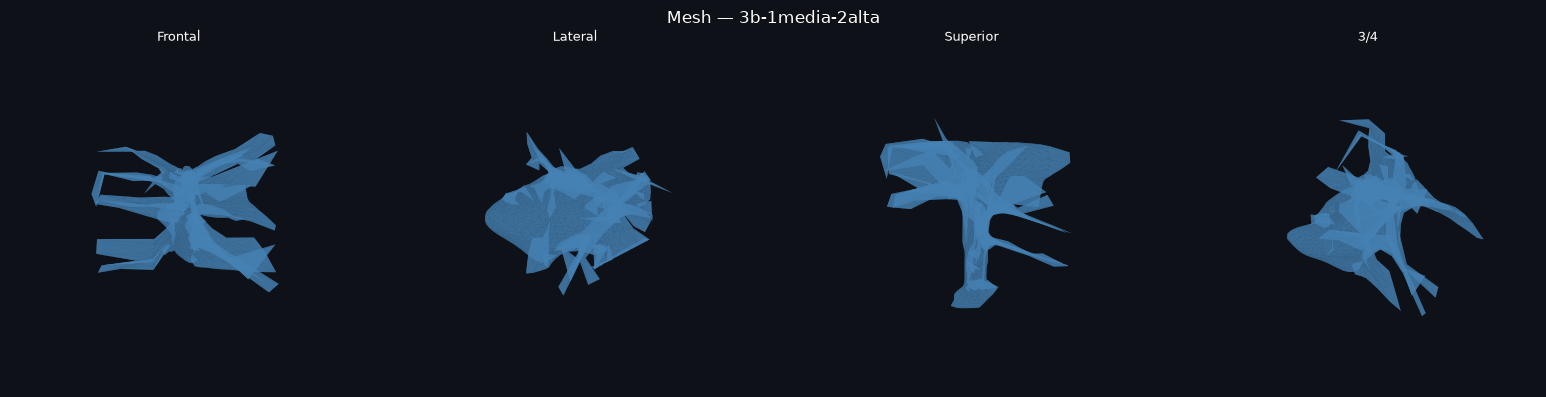

In [27]:
# ── Visualización 3D del mesh optimizado ────────────────────────────────────
import trimesh

def visualize_mesh(exp_id):
    obj_path = os.path.join(ROOT_DIR, exp_id, "sample_0_output.obj")
    if not os.path.exists(obj_path):
        print(f"No encontrado: {obj_path}")
        return
    mesh = trimesh.load(obj_path, force='mesh')
    v, f = np.array(mesh.vertices), np.array(mesh.faces)

    fig = plt.figure(figsize=(16, 4))
    fig.patch.set_facecolor('#0e1117')
    for i, (title, elev, azim) in enumerate([
        ('Frontal', 0, 0), ('Lateral', 0, 90), ('Superior', 90, 0), ('3/4', 25, 45)
    ]):
        ax = fig.add_subplot(1, 4, i+1, projection='3d')
        ax.set_facecolor('#0e1117')
        poly = Poly3DCollection(v[f], alpha=0.6, facecolor='steelblue', edgecolor='none')
        ax.add_collection3d(poly)
        ax.auto_scale_xyz(v[:,0], v[:,1], v[:,2])
        ax.view_init(elev=elev, azim=azim)
        ax.axis('off')
        ax.set_title(title, color='white', fontsize=9)
    fig.suptitle(f'Mesh — {exp_id}', color='white', fontsize=12)
    plt.tight_layout()
    plt.show()

# Ejemplo: visualizar el primer experimento que haya corrido
visualize_mesh("3b-1media-2alta")


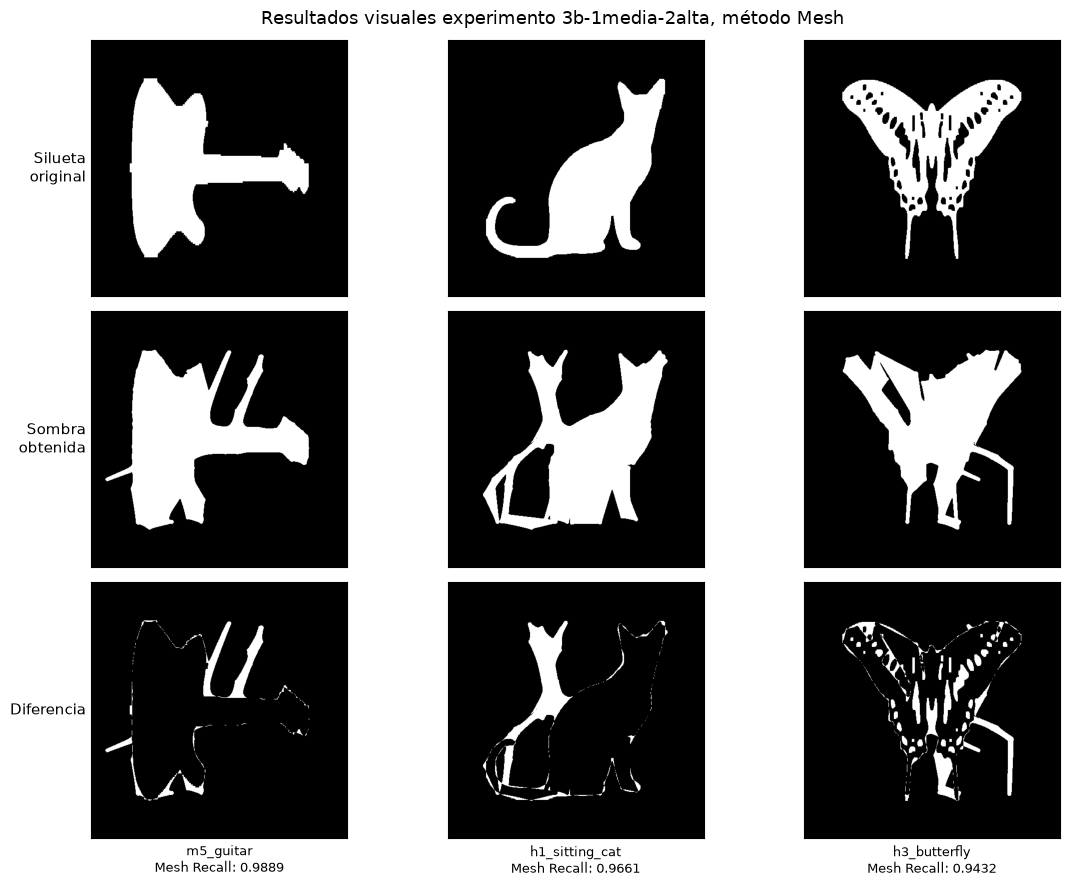

In [28]:
# ── Visualización estilo figura del paper: Silueta | Sombra | Diferencia ────
def visualize_silhouettes(exp_id, images_list=None):
    """Reproduce el estilo de figura del paper: una columna por vista,
    filas fijas (Silueta original / Sombra obtenida / Diferencia) y el
    Recall de cada vista impreso debajo, como en las figuras de Voxel."""
    folder = os.path.join(ROOT_DIR, exp_id)
    if not os.path.exists(folder):
        print(f"No encontrado: {folder}")
        return

    if images_list is None:
        for lookup_name in ("experimentos_por_nombre", "experimentos_espejo_por_nombre"):
            if lookup_name in globals() and exp_id in globals()[lookup_name]:
                images_list = globals()[lookup_name][exp_id]
                break

    num_views = len(images_list) if images_list else len(
        [f for f in os.listdir(folder) if f.startswith("sample_0view_") and f.endswith(".png")]
    )

    fig, axes = plt.subplots(3, num_views, figsize=(4 * num_views, 9))
    if num_views == 1:
        axes = axes[:, None]

    row_labels = ["Silueta\noriginal", "Sombra\nobtenida", "Diferencia"]
    for row, label in enumerate(row_labels):
        axes[row, 0].set_ylabel(label, fontsize=11, rotation=0, ha="right", va="center")

    for idx in range(num_views):
        gt_path   = os.path.join(folder, f"sample_0view_{idx}.png")
        pred_path = os.path.join(folder, f"sample_0_pred_view_{idx}.png")
        gt   = cv2.imread(gt_path,   0)
        pred = cv2.imread(pred_path, 0)
        if gt is None or pred is None:
            print(f"  Falta archivo para vista {idx}, saltando.")
            continue

        _, gt_bin   = cv2.threshold(gt,   127, 255, cv2.THRESH_BINARY)
        _, pred_bin = cv2.threshold(pred, 127, 255, cv2.THRESH_BINARY)
        diff = cv2.bitwise_xor(gt_bin, pred_bin)

        gt_b, pred_b = gt_bin > 0, pred_bin > 0
        tp = np.logical_and(gt_b,  pred_b).sum()
        fn = np.logical_and(gt_b, ~pred_b).sum()
        recall = float(tp / (tp + fn)) if (tp + fn) > 0 else 1.0

        axes[0, idx].imshow(gt_bin,   cmap="gray")
        axes[1, idx].imshow(pred_bin, cmap="gray")
        axes[2, idx].imshow(diff,     cmap="gray")
        for row in range(3):
            axes[row, idx].set_xticks([]); axes[row, idx].set_yticks([])

        nombre = images_list[idx][:-4] if images_list else f"vista_{idx}"
        axes[2, idx].set_xlabel(f"{nombre}\nMesh Recall: {recall:.4f}", fontsize=9)

    fig.suptitle(f"Resultados visuales experimento {exp_id}, método Mesh", fontsize=13)
    plt.tight_layout()
    plt.show()

# Ejemplo de uso:
visualize_silhouettes("3b-1media-2alta")
